
CWID: 20031146

In [90]:
import pandas as pd
import numpy as np
import os
import joblib
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE


# 1. Load Data (Cluster 0)

cluster_id = 0
df = pd.read_csv('train_with_clusters.csv')
df_cluster = df[df['ClusterID'] == cluster_id].copy()
print(f"Number of samples in Cluster {cluster_id}: {len(df_cluster)}")


# 2. Separate Features & Target

X = df_cluster.drop(columns=['Index', 'Bankrupt?', 'ClusterID'])
y = df_cluster['Bankrupt?']


# 3. Feature Selection: SelectKBest with f_classif (Top 25)

# Suppress warnings about constant features and invalid division
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.feature_selection")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.feature_selection")

# Optionally log constant columns
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
if constant_cols:
    print(f"Constant features removed before selection: {constant_cols}")

# SelectKBest
selector = SelectKBest(score_func=f_classif, k=25)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
X = X[selected_features]
print(f"Selected top 25 features: {list(selected_features)}")


# 4. Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 5. Apply SMOTE

print("Applying SMOTE to balance classes...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("Resampled class distribution:")
print(pd.Series(y_resampled).value_counts())


# 6. Define Base Models

base_models = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svm', SVC(probability=True, kernel='rbf', random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
]


# 7. Train Base Models and Evaluate

tt_total = 0
tf_total = 0
fitted_base_models = []

print("\n Base Model Evaluation (on resampled data):")
for name, model in base_models:
    model.fit(X_resampled, y_resampled)
    y_pred_base = model.predict(X_scaled)

    tt_curr = np.sum((y == 1) & (y_pred_base == 1))
    tf_curr = np.sum((y == 1) & (y_pred_base == 0))
    acc_curr = tt_curr / (tt_curr + tf_curr) if (tt_curr + tf_curr) > 0 else 0

    tt_total += tt_curr
    tf_total += tf_curr
    fitted_base_models.append((name, model))

    print(f"Base model '{name}': accuracy={acc_curr:.2f} [{tt_curr}({tf_curr})]")


# 8. Total Base Accuracy

total_acc = tt_total / (tt_total + tf_total) if (tt_total + tf_total) > 0 else 0
print(f"\nTotal Base Model Accuracy: {total_acc:.2f} [{tt_total}({tf_total})]")


# 9. Train Stacking Model

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)
stack_model.fit(X_resampled, y_resampled)

# 10. Evaluate Stacking Model
y_pred_stack = stack_model.predict(X_scaled)
stack_acc = accuracy_score(y, y_pred_stack)

print("\nStacking Model Accuracy on Resampled Data:", stack_acc)
print("Classification Report:\n", classification_report(y, y_pred_stack, zero_division=0))


# 11. Save Model Artifacts

output_dir = f'cluster{cluster_id}_output'
os.makedirs(output_dir, exist_ok=True)

joblib.dump(stack_model, f'{output_dir}/stacked_model_cluster{cluster_id}.pkl')
joblib.dump(scaler, f'{output_dir}/scaler_cluster{cluster_id}.pkl')

with open(f'{output_dir}/selected_features_cluster{cluster_id}.txt', 'w') as f:
    for feat in selected_features:
        f.write(f"{feat}\n")

print(f"\n Model, scaler, and feature list saved in '{output_dir}/'")

Number of samples in Cluster 0: 1196
Constant features removed before selection: ['Liability-Assets_Flag', 'Net_Income_Flag']
Selected top 25 features: ['ROA(C)_before_interest_and_depreciation_before_interest', 'ROA(A)_before_interest_and_%_after_tax', 'ROA(B)_before_interest_and_depreciation_after_tax', 'Pre-tax_net_Interest_Rate', 'After-tax_net_Interest_Rate', 'Non-industry_income_and_expenditure/revenue', 'Continuous_interest_rate_(after_tax)', 'Tax_rate_(A)', 'Net_Value_Per_Share_(C)', 'Persistent_EPS_in_the_Last_Four_Seasons', 'Per_Share_Net_profit_before_tax_(Yuan_¥)', 'Quick_Ratio', 'Interest_Expense_Ratio', 'Total_debt/Total_net_worth', 'Debt_ratio_%', 'Net_worth/Assets', 'Borrowing_dependency', 'Net_profit_before_tax/Paid-in_capital', 'Current_Liability_to_Assets', 'Retained_Earnings_to_Total_Assets', 'Total_income/Total_expense', 'Net_Income_to_Total_Assets', "Net_Income_to_Stockholder's_Equity", 'Liability_to_Equity', 'Equity_to_Liability']
Applying SMOTE to balance classe


Confusion Matrices for Base Models:
Base model 'knn': accuracy=1.00 [29(0)]
Base model 'svm': accuracy=1.00 [29(0)]
Base model 'rf': accuracy=1.00 [29(0)]

Total Base Model Accuracy: 1.00 [87(0)]


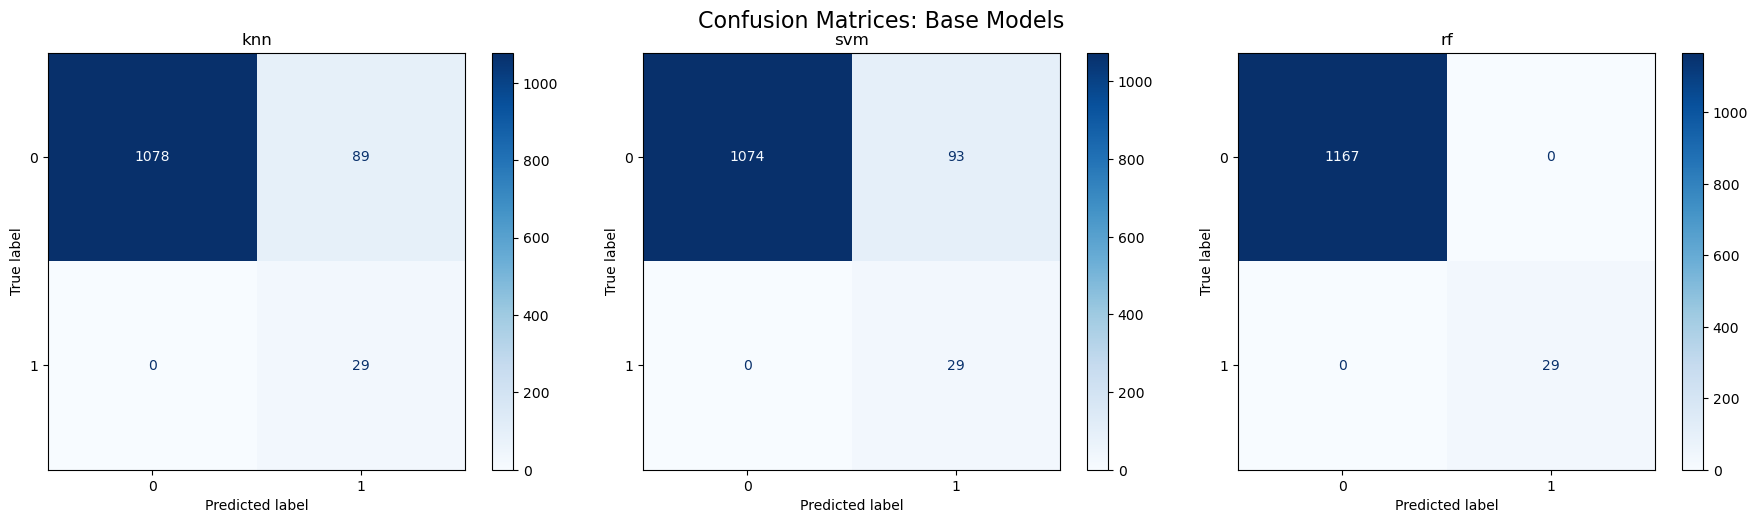


Meta Model (Stacking): accuracy=1.00 [29(0)]


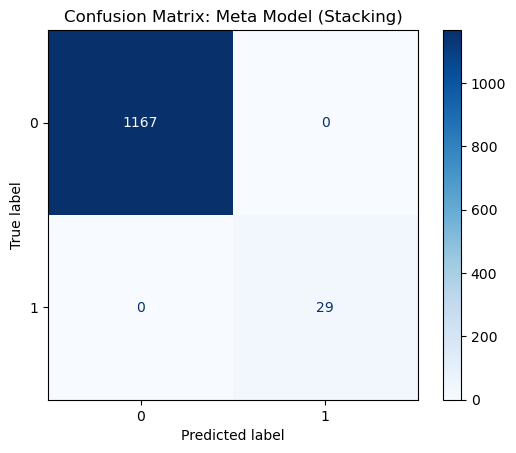


Meta Model Classification Report:
                  precision    recall  f1-score   support

Not Bankrupt (0)       1.00      1.00      1.00      1167
    Bankrupt (1)       1.00      1.00      1.00        29

        accuracy                           1.00      1196
       macro avg       1.00      1.00      1.00      1196
    weighted avg       1.00      1.00      1.00      1196



In [91]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Suppress common ML warnings
warnings.filterwarnings("ignore")


# 1. Base Models Evaluation

tt_total = 0
tf_total = 0
pred_base = {}

print("\nConfusion Matrices for Base Models:")
num_cols = len(fitted_base_models)
fig, axes = plt.subplots(1, num_cols, figsize=(6 * num_cols, 5))
axes = axes.flatten()

for i, (name, model) in enumerate(fitted_base_models):
    y_pred = model.predict(X_scaled)
    pred_base[name] = y_pred

    # True positives and false negatives for bankrupt=1
    tt_curr = np.sum((y == 1) & (y_pred == 1))
    tf_curr = np.sum((y == 1) & (y_pred == 0))
    acc_curr = tt_curr / (tt_curr + tf_curr) if (tt_curr + tf_curr) > 0 else 0

    tt_total += tt_curr
    tf_total += tf_curr

    print(f"Base model '{name}': accuracy={acc_curr:.2f} [{tt_curr}({tf_curr})]")

    # Plot confusion matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}')

# Summary of base models
total_acc = tt_total / (tt_total + tf_total) if (tt_total + tf_total) > 0 else 0
print(f"\nTotal Base Model Accuracy: {total_acc:.2f} [{tt_total}({tf_total})]")

plt.suptitle('Confusion Matrices: Base Models', fontsize=16)
plt.tight_layout()
plt.show()


# 2. Stacking Model Evaluation

y_pred_stack = stack_model.predict(X_scaled)

tt_meta = np.sum((y == 1) & (y_pred_stack == 1))
tf_meta = np.sum((y == 1) & (y_pred_stack == 0))
acc_meta = tt_meta / (tf_meta + tt_meta) if (tf_meta + tt_meta) > 0 else 0

print(f"\nMeta Model (Stacking): accuracy={acc_meta:.2f} [{tt_meta}({tf_meta})]")

# Confusion matrix
cm_stack = confusion_matrix(y, y_pred_stack)
disp_stack = ConfusionMatrixDisplay(confusion_matrix=cm_stack, display_labels=[0, 1])
disp_stack.plot(cmap='Blues')
plt.title('Confusion Matrix: Meta Model (Stacking)')
plt.show()

# Classification Report
print("\nMeta Model Classification Report:")
print(classification_report(y, y_pred_stack, target_names=["Not Bankrupt (0)", "Bankrupt (1)"], zero_division=0))